## Cas concret avec l'expérience

Dans cette partie on reprends le bon Hamiltonien, c'est à dire : 
$$
\begin{align*}
\dfrac{\partial \mathcal{H}}{\partial p_x} &=& \dfrac{eB v_F^2 p_x}{c\varepsilon(p)} \\
\dfrac{\partial \mathcal{H}}{\partial p_y} &=& \dfrac{eB}{c}\left( \dfrac{v_F^2 p_y}{\varepsilon(p)}+ v_d\right)
\end{align*}
$$

Posons $G:=\dfrac{\Delta t eB \ v_F^2}{c \ \varepsilon(p)}$, alors comme dans le cas jouet on peut réécrire le schéma symplectique :
$$
P^{n+1} = \begin{bmatrix} 1 -G^2 & G \\ -G & 1 \end{bmatrix} \times P^n + \begin{bmatrix} \dfrac{\Delta t \ eB}{c} v_d \\ 0 \end{bmatrix}
$$


In [ ]:
# Packages ------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pyhamsys import HamSys, solve_ivp_sympext, Parameters
from scipy.signal import find_peaks

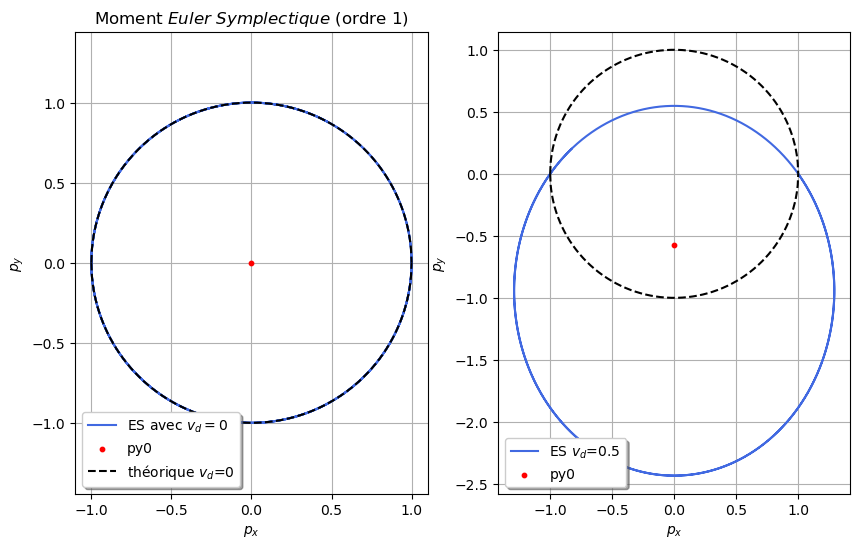

In [277]:
# Euler Symplictique Définition -----------------------------
""" Ce schéma n'est correct que pour l'Hamiltonien défini par le papier de Sergey Krishtopenko. """
def varepsilon(p):
    px = p[0]
    py = p[1]
    return np.sqrt(M**2 + vf**2 * (px**2 + py**2))

def ES(deltaT, T, P, e, B, vf, c, varepsi, vd):
    '''
    deltaT = Pas de temps
    T : temps final
    e : charge de l'électron
    B : champs magnétique       # prendre .7
    vf : vitesse de fermi
    c : vitesse de la lumière
    varepsi : fonction bande qui dépend de P
    vd: vitesse drift (E/B)
    '''
    Drift_matrix = np.array([deltaT * e * B * vd /c, 0])
    N = int(np.floor(T / deltaT))
    P_trajectory = np.zeros((N, 2))
    P_trajectory[0] = P
# --------------------------------
    for i in range(1, N): 
        G = (deltaT * e * B * vf**2) / (c * varepsi(P_trajectory[i-1]))
        Iteration_matrix = [[1 - G**2, G], [-G, 1]]
        P = Iteration_matrix @ P_trajectory[i-1] + Drift_matrix
        P_trajectory[i] = P
    return P_trajectory
# test ---choix des valeurs au hasard-----------------------------------------------------

P = np.array([1, 0])
e = 1
B = 0.7
vf = 1
c = 1
vd = 0.5# 0.1
M=1
py0 =  -vd * M / (vf * np.sqrt(vf**2 - vd**2))


def W(P):
   return varepsilon(P) + vd * P[1]

def omega_c(W):
   return (e * B / c) * ( vf**2 / W(P)) * (1 - vd/vf)**(3/2) 

T = 2 * np.pi / omega_c(W)
deltaT = 1E-4


# ----------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,6))

traj_ES = ES(deltaT, T, P, e, B, vf, c, varepsilon, 0)
ax1.plot(traj_ES[:, 0], traj_ES[:,1], color='royalblue',label=r'ES avec $v_d=0$')
ax1.scatter(0, 0, marker='o', s=10, color='red', zorder=3, label='py0' ) # vd = 0 donc py0 = 0
# ax1.plot(traj_ES[1, 0], traj_ES[0,1], marker='s', color='red',label='Premier')
# ax1.plot(traj_ES[-1, 0], traj_ES[-1, 1], marker='.', color='black',label='Dernier')


x = np.linspace(-1, 1, 500)
ax1.plot(x, np.sqrt(1-x**2), color='black', linestyle='--', label=r'théorique $v_d$=0')
ax1.plot(x, -np.sqrt(1-x**2), color='black', linestyle='--')

ax1.set_xlabel(r'$p_x$')
ax1.set_ylabel(r'$p_y$')
ax1.set_title(r'Moment $Euler \ Symplectique$ (ordre 1)')
ax1.axis('equal')
ax1.grid()
ax1.legend(shadow=True, loc= 'lower left')
# -------------------------------------------------------------------------------------------------
traj_ES = ES(deltaT, T, P, e, B, vf, c, varepsilon, vd)
ax2.plot(traj_ES[:, 0], traj_ES[:,1], color='royalblue',label=fr'ES $v_d$={vd}')
ax2.scatter(0, py0, marker='o', s=10, color='red', zorder=3, label='py0' ) 
# ax2.plot(traj_ES[0,0], traj_ES[0, 1], color='black', marker='o', label='initial')
# ax2.plot(traj_ES[-1,0], traj_ES[-1, 1], color='red', marker='o', label='final')

x = np.linspace(-1, 1, 500)
ax2.plot(x, np.sqrt(1-x**2), color='black', linestyle='--')
ax2.plot(x, -np.sqrt(1-x**2), color='black', linestyle='--')

ax2.legend(shadow=True, loc= 'lower left')
ax2.set_xlabel(r'$p_x$')
ax2.set_ylabel(r'$p_y$')
ax2.axis('equal')
ax2.grid()

plt.show()


### Bande Fermions de Dirac (et Graphène $G0$ en option)
On compare le résultat précédent avec les résultats obtenus avec des méthodes de la libraire PyHamSys.
Puis on ajoute un méthode pour faire la même chose avec une bande de graphène G0 (identique à ce qu'on utilise pour le code "streaming example")

        Computation finished in 10 seconds


Choix système : p_system


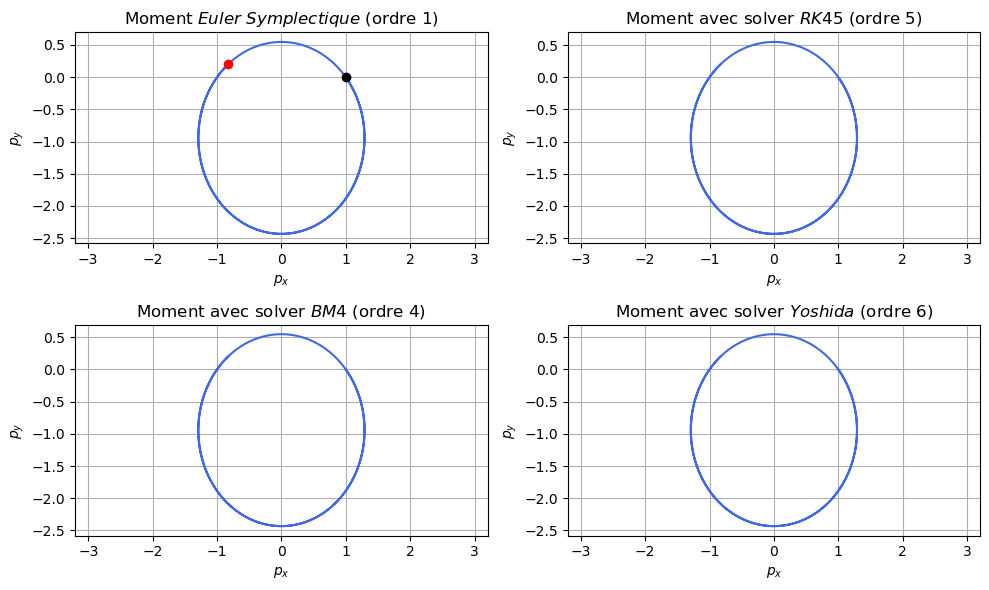

Les pas de temps pour ES et RK4 sont de :0.001 
Pour BM4 et Yoshida on utilise delta t = 0.1


In [278]:
# Code avec PyHamSys ------------------------
# (Cette cellule utilise du code de la cellule précédente)

# Hamiltonien Défintion
hs = HamSys(ndof=1)
P = np.array([1, 0])
e = 1
B = 0.7
vf = 1
c = 1
vd = 0.5 #5.0

deltaT = 1e-3
deltaT_BM4_Yoshida = 0.1

def W(P):
   return varepsilon(P) + vd * P[1]
W0 = W(P)

def omega_c(W):
   return (e * B / c) * ( vf**2 / W(P)) * (1 - vd/vf)**(3/2)


T = 2 * np.pi / omega_c(W)
time_range = np.linspace(0, T , int((np.floor(T /deltaT)))) 

# ------------------------------------------------------------------------

def p_system(t, y): #resolution papier
    G =  (e * B / c)
    q, p = np.split(y, 2)
    y0 =  G * ((vf**2 * p / varepsilon(y)) + vd) 
    y1 = -G * ((vf**2 * q / varepsilon(y)))

    return np.concatenate((y0, y1), axis=None)

def y_dot_G0(t, y):   # for graphene (benoit)
    q, p = y[0], y[1]
    y0 =    p * (1+q*q)/2+ vd
    y1 =   -q*  (1+p*p)/2
    return np.array([y0, y1])

# ES_graphene ---------------------------------------------------------
def ES_graphene(deltaT, T, P, vd):
    '''
    deltaT = Pas de temps
    vd: vitesse drift (e/B)
    '''
    N = int(np.floor(T/ deltaT))
    P_trajectory = np.zeros((N, 2))
    P_trajectory[0] = P
    lmbda = deltaT / 2
    for i in range(1, N):
        A, B = P_trajectory[i-1][0], P_trajectory[i-1][1]
        Y = B - lmbda * (A + A * B**2)
        discriminant = 1 - 4 * lmbda * Y * ( lmbda * Y + A + deltaT * vd)
        X1 = (1 + np.sqrt(discriminant)) / (2 * lmbda * Y)
        X2 = (1 - np.sqrt(discriminant)) / (2 * lmbda * Y)

        '''
        Pour le choix de X j'ai d'abord choisi de prendre le plus petit de façon arbitraire.
        Ensuite j'ai voulu regarder laquelle des deux valeurs est la plus proche de l'anciene et en comparant avec l'ancienne méthode on retrouve le même résultat.
        On trouve un résulat proche des solveurs de PyHamsys.
        Même chose pour le choix selon la conservation de l'energie.
        '''

        # X = X1 if abs(X1 - A) < abs(X2 - A) else X2
        X = X1 if abs(W([X1,Y]) - W0) < abs(W([X2,Y] - W0)) else X2

        P_trajectory[i] = [X, Y]
    return P_trajectory

# resolution ---------------------------------------------------------

system_liste = [p_system] #, y_dot_G0] # On retire finalement G0 car le cas n'est pas pertinent
for i, name in enumerate(system_liste):
    hs.y_dot = name # choix du système
    sol_BM4 = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT_BM4_Yoshida, solver='BM4'))
    # sol_Verlet = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Verlet'))
    sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT_BM4_Yoshida, solver='Yos6'))
    if i == 0:
        Moment_ES = ES(deltaT, T, P, e, B, vf, c, varepsilon, vd)
    else :
        Moment_ES_graphene = ES_graphene(deltaT, T, P, vd)
    
    sol_RK45 = hs.integrate( P, time_range, params=Parameters(step=deltaT, solver='RK45'))
    # Plot ------------------------------------------
    print(f'Choix système : {name.__name__}')
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,6))
    if i == 0:
        ax1.plot(Moment_ES[:, 0], Moment_ES[:,1], color='royalblue',label='ES')
        ax1.plot(Moment_ES[-1, 0], Moment_ES[-1, 1], marker='o', color='red',label='Dernier')
        ax1.plot(Moment_ES[1, 0], Moment_ES[1,1], marker='o', color='black',label='Premier')

        ax1.set_xlabel(r'$p_x$')
        ax1.set_ylabel(r'$p_y$')
        ax1.set_title(r'Moment $Euler \ Symplectique$ (ordre 1)')
        
    else :
        ax1.plot(Moment_ES_graphene[:, 0], Moment_ES_graphene[:,1] ,color='royalblue',label='ES')
        # ax1.plot(Moment_ES_graphene[-1, 0], Moment_ES_graphene[-1, 1], marker='o', color='red',label='Dernier')
        # ax1.plot(Moment_ES_graphene[-2, 0], Moment_ES_graphene[-2,1], marker='o', color='black',label='Avant-Dernier')
        ax1.set_xlabel(r'$p_x$')
        ax1.set_ylabel(r'$p_y$')
        ax1.set_title(r'Moment $Euler \ Symplectique$ (ordre 1)')        

    ax2.plot(sol_RK45.y[0], sol_RK45.y[1], color='royalblue')
    ax2.set_xlabel(r'$p_x$')
    ax2.set_ylabel(r'$p_y$')
    ax2.set_title(r'Moment avec solver $RK45$ (ordre 5)')
    

    ax3.plot(sol_BM4.y[0], sol_BM4.y[1], color='royalblue')
    ax3.set_xlabel(r'$p_x$')
    ax3.set_ylabel(r'$p_y$')
    ax3.set_title(r'Moment avec solver $BM4$ (ordre 4)')
    
    

    ax4.plot(sol_Yoshida.y[0], sol_Yoshida.y[1], color='royalblue')
    ax4.set_xlabel(r'$p_x$')
    ax4.set_ylabel(r'$p_y$')
    ax4.set_title(r'Moment avec solver $Yoshida$ (ordre 6)')
    ax1.grid(), ax2.grid(), ax3.grid(), ax4.grid()
    ax1.axis('equal'), ax2.axis('equal'), ax3.axis('equal'), ax4.axis('equal')
    plt.tight_layout()
    plt.show()

# print(f'Avant dernier point ES_graphène : [{np.round(Moment_ES_graphene[-2, 0], 3)},  {np.round(Moment_ES_graphene[-2,1],3)}] ')
# print(f'Avant Dernier point RK45 : [ {np.round(sol_RK45.y[0][-2],3)}, {np.round(sol_RK45.y[1][-2],3)} ] ')
# print(f'Avant Dernier point BM4 : [ {np.round(sol_BM4.y[0][-2],3)}, {np.round(sol_BM4.y[1][-2], 3)} ] ')
# print(f'Avant Dernier point Yoshida: [ {np.round(sol_Yoshida.y[0][-2],3)}, {np.round(sol_Yoshida.y[1][-2], 3)} ] ')

# print(f'Dernier point ES_graphène : [{np.round(Moment_ES_graphene[-1, 0], 3)},  {np.round(Moment_ES_graphene[-1,1],3)}] ')
# print(f'Dernier point RK45 : [ {np.round(sol_RK45.y[0][-1],3)}, {np.round(sol_RK45.y[1][-1],3)} ] ')
# print(f'Dernier point BM4 : [ {np.round(sol_BM4.y[0][-1],3)}, {np.round(sol_BM4.y[1][-1],3)} ] ')
# print(f'Dernier point Yoshida: [ {np.round(sol_Yoshida.y[0][-1],3)}, {np.round(sol_Yoshida.y[1][-1], 3)} ] ')
print(f'Les pas de temps pour ES et RK4 sont de :{deltaT} ')
print(f'Pour BM4 et Yoshida on utilise delta t = {deltaT_BM4_Yoshida}')

## Calcul de la période pour les Fermions de Dirac
Après plusieurs tentative raté, je n'ai malheureusement par réussi à utiliser ce théorème pour calculer la période... Je garde des notes ici et plus tard dans ce notebook mais qui ne représente pas l'hamiltonien utilisé ou en tout cas, a sûrement était mal adapté...
Pour étudier la période j'ai finalement utilisé  "find peaks" qui permet de trouver les maximaux d'une fonction. Puisque le système décrit une orbite stable le mouvement en $p_x$ et $p_y$ va être périodique. On observera plusieurs fois une même maxmimum on se servira de ces valeurs pour trouver la période...
Cette méthode est forcément moins bien puisqu'elle fait appel au moment décrit par le schéma choisi. Un schéma imprécis risque donc de donner une périiode éloigné de la période réelle. Ici on fait le choix d'estimer la période à l'aide du solver de Yoshida qui présentait des résultats très proche de la solution de la solution théorique dans des temps acceptables.

----------------------------------------------------------------------------------------------
On utilise la méthode vu dans le papier de Lokta-Volterra pour calculer la période $\mathcal{T}$:
$$d
\mathcal{T} = \int^{2\pi}_0 \dfrac{d\theta}{\mathcal{F}(\theta)}
$$
Avec:
$$
\mathcal{F}(\theta) = \dfrac{\partial_r F(g(\theta), \theta)}{g(\theta)}
$$
En précisant que:
$$
\begin{aligned}
F(r,\theta) &= H(r\cos(\theta), r\sin(\theta)) - H(p0, q0) \\
F(g(\theta), \theta) &= 0
\end{aligned}
$$
Où $(p0, q0) = (0,0)$ est le point d'équilibre et g est défini implictement.

En repartant du problème:
$$
\begin{align*}
\dfrac{\partial \mathcal{H}}{\partial p_x} &=& \dfrac{eB v_F^2 p_x}{c\varepsilon(p)} \\
\dfrac{\partial \mathcal{H}}{\partial p_y} &=& \dfrac{eB}{c}\left( \dfrac{v_F^2 p_y}{\varepsilon(p)}+ v_d\right)
\end{align*}
$$
On trouve (je détaillerai plus tard mais on a posé $\tilde{p_y} = p_y^0 + p_y  $ de sorte que le point d'équilibre soit centré en $(0,0)$ et où $p_y^0 = - \dfrac{M v_d}{v_f(v_f^2 - v_d^2)^{1/2}}$):
$$
F(r,\theta) = G\left(M^2 + v_F^2(r^2 - 2r\sin(\theta)p_y^0 + (p_y^0)^2)\right)^{1/2} + G v_d r \sin(\theta) - G(M^2 + v_F^2 (p_y^0)^2)^{1/2}
$$
Et
$$
\partial_r F(r, \theta) = \dfrac{G v_f^2 (r - \sin{\theta} p_y^0)}{r^2 - 2r\sin(\theta) p_y^0 + (p_y^0)^2} + G v_d \sin(\theta)
$$

Il nous reste donc à calculer:
$$
\mathcal{T} = \int^{2\pi}_0 \dfrac{g(\theta)}{\partial_r F(g(\theta), \theta)}(d\theta)
$$
Et pour calculer $g(\theta)$ on utilise une méthode de Newton puis pour calculer l'intégrale on utilise une méthode des trapèzes comme dans le papier.

------------------------------------------------------------------------------------------------
Le code qui suit est donc une tentative raté de l'application de ce théorème. La cellule suivante comporte des résultats plus réussi.

 On pose r et theta tq cela donne nos conditions initiales:
    rcos(theta) = 0
    rsin(theta) = py0
    Donc 
    r = sqrt(py0^2)
    theta = arctan(py0 / 0)  PROBLEME
    
    F(r, theta) = 0.05890469107451757

T = 11.967972013014526


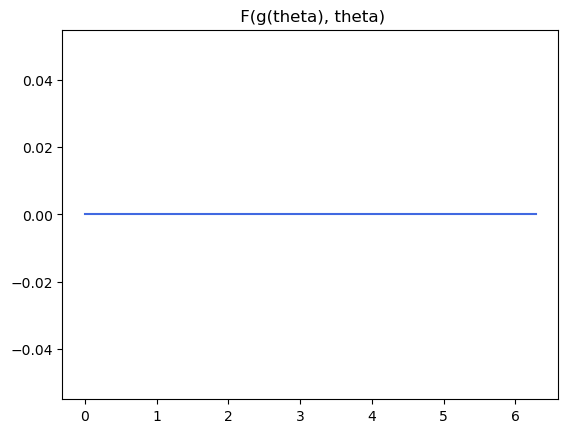

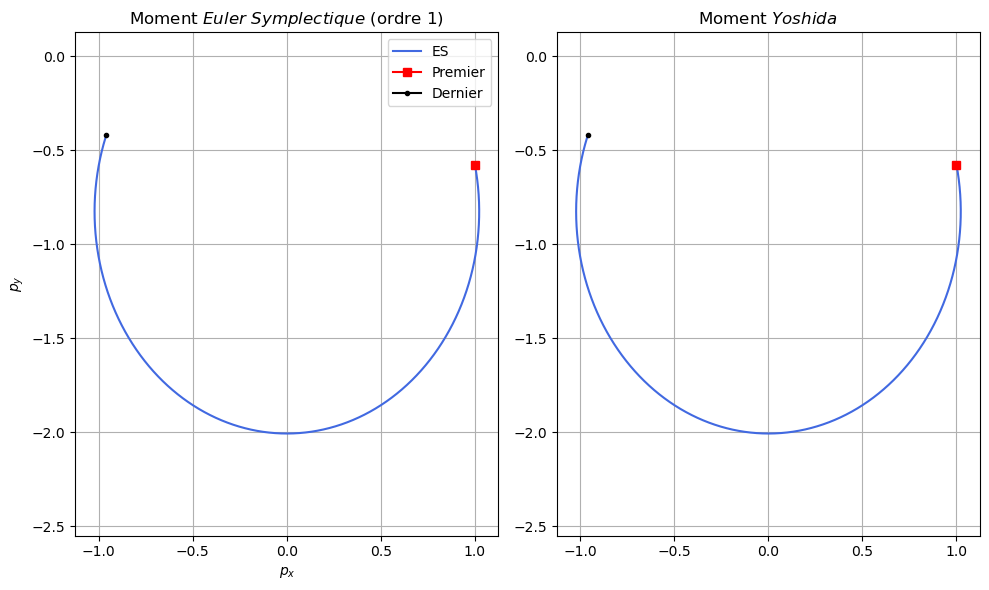

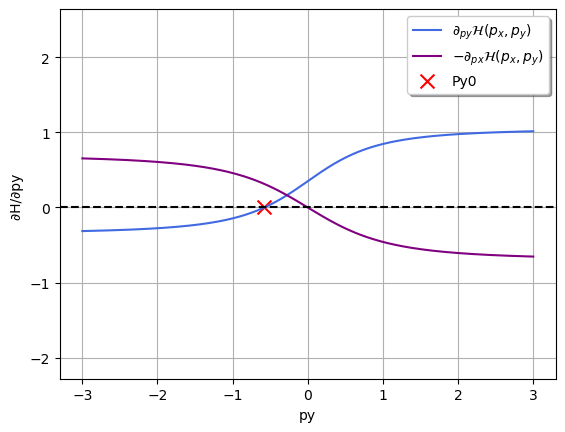

In [ ]:
# Paramètres physiques
e = 1
B = 0.7
c = 1
vf = 1.0
vd = 0.5
M = 1.0
G = e * B / c

# Point d'équilibre à l'état initial
py0 =  -vd * M / (vf * np.sqrt(vf**2 - vd**2))

# Condition initiale pour Newton
px_initial = 1
py_initial = 0

r0 = np.sqrt(px_initial**2 + py_initial**2)


# ---------------------------------------------------------------------------------------
def esp(px, py):
    return np.sqrt(M**2 + vf**2 *(px**2 + (py)**2))

def H(px, py):
    return G * (esp(px, py) + vd * (py))

# ---------------------------------------------------------------------------------------
def F(r, theta, py0):
    px = r * np.cos(theta)
    py = py0 + r * np.sin(theta)
    return H(px, py) - H(0, py0)

def Df(r, theta, py0):
    px = r * np.cos(theta)
    py = py0 + r * np.sin(theta)
    denom = np.sqrt(M**2 + vf**2 * (px**2 + py**2))
    return G * (vf**2 * (px * np.cos(theta) + py * np.sin(theta))/ denom + vd * np.sin(theta))
# -----------------------------------------------------------------------------------------
def g_newton(theta, r0, n_iter=100, tol=1e-16):
    r = r0
    for _ in range(n_iter):

        f  = F(r, theta, py0)
        df = Df(r, theta, py0)  

        r = r - f / df
        
        if abs(f) < tol:
            break
    return r
def py0_newton():
    return 
print(f''' On pose r et theta tq cela donne nos conditions initiales:
    rcos(theta) = 0
    rsin(theta) = py0
    Donc 
    r = sqrt(py0^2)
    theta = arctan(py0 / 0)  PROBLEME
    
    F(r, theta) = { F(np.sqrt(py0**2), np.arctan(py0/1E-16), py0)}
''')

def periode(N_theta=int(100)):
    thetas  = np.linspace(0, 2*np.pi, N_theta)
    valeurs = np.zeros(N_theta)
    residus = np.zeros(N_theta)
    
    r = r0
    for i, t in enumerate(thetas):
        
        g_theta = g_newton(t, r)
        residus[i] =(F(g_theta, t, py0))
        df = Df(g_theta, t, py0)
        valeurs[i] = g_theta / df
        r = g_theta
        
    plt.plot(thetas, residus, color="royalblue") # pour vérifier que Newton marche bien
    plt.title(" F(g(theta), theta)")
   
    Periode = np.trapezoid(valeurs, thetas, dx=thetas[1]-thetas[0])
    return Periode
#---------------------------------------------------------------------------------------
T= periode()
print(f"T = {T}")

P = np.array([px_initial, py_initial + py0])

deltaT = 1e-4
Moment_ES = ES(deltaT, T , P, e, B, vf, c, varepsilon, vd)

hs.y_dot = p_system
deltaT_Yoshida= 0.002
sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT_Yoshida, solver='Yos6'))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,6))
ax1.plot(Moment_ES[:, 0], Moment_ES[:,1], color='royalblue',label='ES')
ax1.plot(Moment_ES[1, 0], Moment_ES[0,1], marker='s', color='red',label='Premier')
ax1.plot(Moment_ES[-1, 0], Moment_ES[-1, 1], marker='.', color='black',label='Dernier')

ax1.set_xlabel(r'$p_x$')
ax1.set_ylabel(r'$p_y$')
ax1.set_title(r'Moment $Euler \ Symplectique$ (ordre 1)')
ax1.axis('equal')
ax1.grid()
ax1.legend()



ax2.plot(sol_Yoshida.y[0], sol_Yoshida.y[1], color='royalblue')
ax2.plot(sol_Yoshida.y[0][0], sol_Yoshida.y[1][0], color='red', marker='s')
ax2.plot(sol_Yoshida.y[0][-1], sol_Yoshida.y[1][-1], color='black', marker='.')
ax2.set_title(r'Moment $Yoshida$ ')
ax2.grid()
ax2.axis('equal')
plt.tight_layout()
plt.show()
    
#----------------------------------------------------------------------------------------------------------------------------------

pys = np.linspace(-3, 3, 300)
dHdpy = np.array([G *( (vf**2 * py / esp(0, py)) + vd) for py in pys])
dHdpx = np.array([G * (vf**2 * px / esp(px, py0)) for px in pys])
plt.plot(pys, dHdpy, color='royalblue', label=r'$\partial_{py}\mathcal{H}(p_x,p_y)$')
plt.plot(pys, -dHdpx, color='purple', label=r'$-\partial_{px}\mathcal{H}(p_x,p_y)$')

plt.scatter(py0, 0, marker='x', color='red', label='Py0', s=100)
plt.axhline(0, color='k', linestyle='--')
plt.legend(shadow=True)
plt.xlabel('py')
plt.ylabel('∂H/∂py ')
plt.axis('equal')
plt.grid()
plt.show()

############################---------######################"||||||||||#'tgregsrfgoffiiiiiiiiiiiiiiiiiiiiiiiii"
# # Condition initiale pour Newton
# r0 = np.sqrt(px_initial**2 + py_initial**2)


# # ---------------------------------------------------------------------------------------
# def esp(px, py):
#     return np.sqrt(M**2 + vf**2 *(px**2 + py**2))

# def H(px, py):
#     return G * (esp(px, py) + vd * (py))

# # ---------------------------------------------------------------------------------------
# def F(r, theta):
#     return H(r * np.cos(theta), r * np.sin(theta)) - H(0, py0)

# def Df(r, theta):
#     denom = np.sqrt(M**2 + vf**2 * (r**2 - 2*r*np.sin(theta)*py0 + py0**2))
#     return G * vf**2 * (r - np.sin(theta)*py0) / denom + G * vd * np.sin(theta)
# # -----------------------------------------------------------------------------------------
# def g_newton(theta, r0, n_iter=100, tol=1e-16):
#     r = r0
#     for _ in range(n_iter):

#         f  = F(r, theta)
#         df = Df(r, theta)  

#         r = r - f / df
        
#         if abs(f) < tol:
#             break
#     return r

# def periode(N_theta=100):
#     thetas  = np.linspace(0, 2*np.pi, N_theta)
#     valeurs = np.zeros(N_theta)
#     residus = np.zeros(N_theta)
    
#     r = r0
#     for i, t in enumerate(thetas):
        
#         g_theta = g_newton(t, r)
#         residus[i] =(F(g_theta, t))
#         df = Df(g_theta, t)
#         valeurs[i] = g_theta / df
        
        
#     plt.plot(thetas, residus, color="royalblue") # pour vérifier que Newton marche bien
#     plt.title(" F(g(theta), theta)")
   
#     Periode = np.trapezoid(valeurs, thetas, dx=thetas[1]-thetas[0])
#     return Periode
# #---------------------------------------------------------------------------------------
# T= periode()
# print(f"T = {T}")

# deltaT = 1e-4
# Moment_ES = ES(deltaT, T , P, e, B, vF, c, varepsilon, vd)

# plt.figure()
# plt.plot(Moment_ES[:, 0], Moment_ES[:,1], color='royalblue',label='ES')
# plt.plot(Moment_ES[1, 0], Moment_ES[0,1], marker='s', color='red',label='Premier')
# plt.plot(Moment_ES[-1, 0], Moment_ES[-1, 1], marker='.', color='black',label='Dernier')

# plt.xlabel(r'$p_x$')
# plt.ylabel(r'$p_y$')
# plt.title(r'Moment $Euler \ Symplectique$ (ordre 1)')
# plt.axis('equal')
# plt.grid()
# plt.tight_layout()
# plt.legend()
# plt.show()
# # ------------------------------------------------------------------------
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,6))

# pys = np.linspace(-3, 3, 300)
# dHdpy = [(H(0, py + 1e-8) - H(0, py - 1e-8)) / 2e-8 for py in pys]
# ax1.plot(pys, dHdpy)
# ax1.axhline(0, color='k', linestyle='--')
# ax1.set_xlabel('py')
# ax1.set_ylabel('∂H/∂py à px=0')
# ax1.set_title('dyH en version numérique')
# ax1.grid()

# pys = np.linspace(-3, 3, 300)
# dHdpy =[ G *( (vf**2 * py / esp(0, py)) + vd) for py in pys]
# ax2.plot(pys, dHdpy)
# ax2.axhline(0, color='k', linestyle='--')
# ax2.set_xlabel('py')
# ax2.set_ylabel('∂H/∂py à px=0')
# ax2.set_title('dyH Analytique')
# ax2.grid()
# plt.tight_layout()
# plt.show()

T = 19.544022798860055


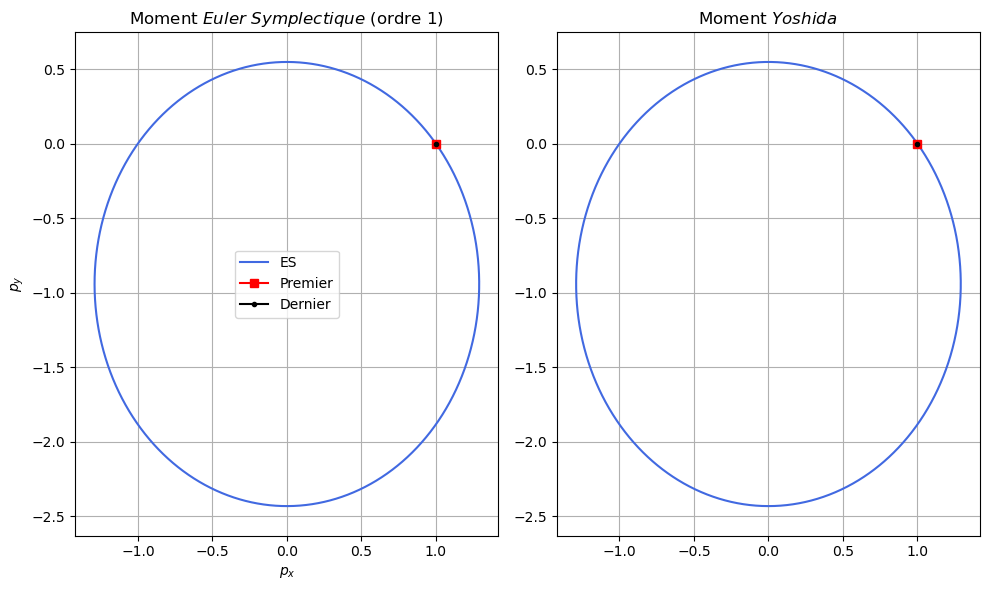

In [295]:
def find_periode(P, T_long, vd_para, B_para, E_para, precision_yoshida=0.1, systeme_hamiltonien=p_system ):
    '''
    On cherche la période numériquement 
    On peut faire varier vd, B et E
    T_Long doit être beaucoup plus long que le temps estimé pour avoir plusieurs périodes.
    '''
    global vd, B, E

    vd = vd_para
    B = B_para
    E = E_para
    hs.y_dot = systeme_hamiltonien
    deltaT_Yoshida = precision_yoshida
    sol_long = solve_ivp_sympext(hs, t_span=(0, T_long), y0=P, params=Parameters(step=deltaT_Yoshida, solver='Yos6'))

    py_traj = sol_long.y[1]
    peaks, properties = find_peaks(py_traj, np.mean(py_traj))  
    t_peaks = sol_long.t[peaks]
    # valeurs_max = properties["peaks_heights"]

    # print(f"Liste Périodes : {np.diff(t_peaks)}")
    # print(f"Période médianne : {np.median(np.diff(t_peaks))}")

    periode = np.median(np.diff(t_peaks))
    return periode


px_initial = 1
py_initial = 0

P = np.array([px_initial, py_initial])

T= find_periode(P, 100, vd, B, E, 0.005)
print(f"T = {T}")

deltaT = 1e-4
Moment_ES = ES(deltaT, T , P, e, B, vf, c, varepsilon, vd)

hs.y_dot = p_system
deltaT_Yoshida= 0.02
sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT_Yoshida, solver='Yos6'))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,6))
ax1.plot(Moment_ES[:, 0], Moment_ES[:,1], color='royalblue',label='ES')
ax1.plot(Moment_ES[1, 0], Moment_ES[0,1], marker='s', color='red',label='Premier')
ax1.plot(Moment_ES[-1, 0], Moment_ES[-1, 1], marker='.', color='black',label='Dernier')

ax1.set_xlabel(r'$p_x$')
ax1.set_ylabel(r'$p_y$')
ax1.set_title(r'Moment $Euler \ Symplectique$ (ordre 1)')
ax1.axis('equal')
ax1.grid()
ax1.legend()

ax2.plot(sol_Yoshida.y[0], sol_Yoshida.y[1], color='royalblue')
ax2.plot(sol_Yoshida.y[0][0], sol_Yoshida.y[1][0], color='red', marker='s')
ax2.plot(sol_Yoshida.y[0][-1], sol_Yoshida.y[1][-1], color='black', marker='.')
ax2.set_title(r'Moment $Yoshida$ ')
ax2.grid()
ax2.axis('equal')
plt.tight_layout()
plt.show()

c:\Users\Hugo Johnson\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Hugo Johnson\anaconda3\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


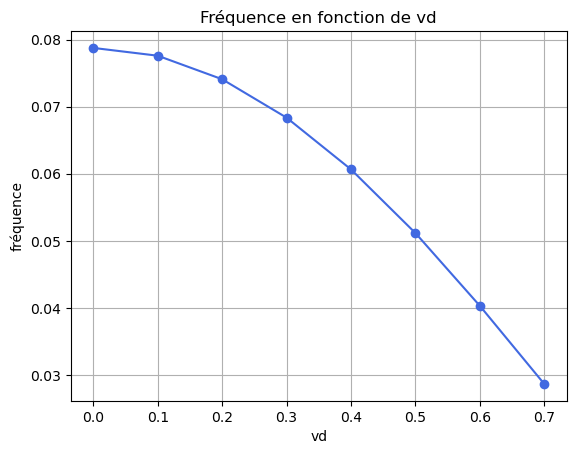

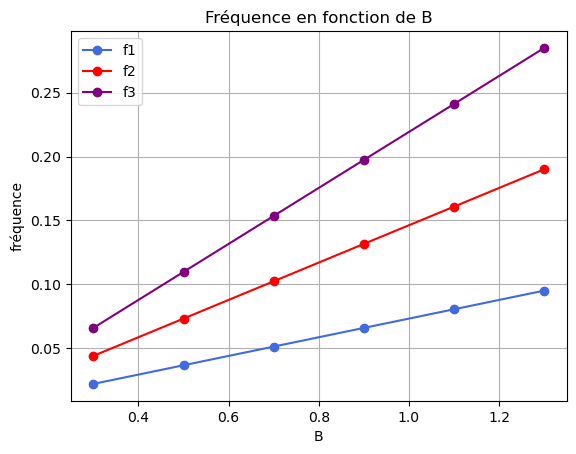

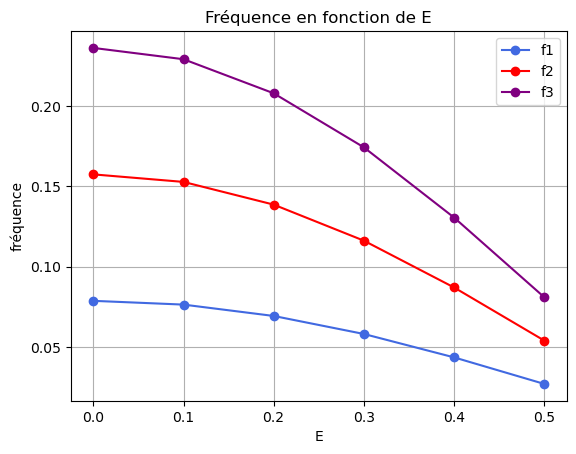

In [297]:
##### SUITE #################################
vd_tab = np.array([0, 0.1, 0.2, 0.3 , 0.4, 0.5, 0.6, 0.7, 0.8, 0.9 ])
periode_tab = np.zeros_like(vd_tab)

for i, vd in enumerate(vd_tab):
    T = find_periode(P, 100, vd, B, E, 0.01)
    periode_tab[i] = T

frequence = 1 / periode_tab
plt.figure()
plt.plot(vd_tab, frequence, marker='o', color='royalblue')
plt.xlabel("vd")
plt.ylabel("fréquence")
plt.title("Fréquence en fonction de vd")
plt.grid()
plt.show()


B_tab = np.array([0.3, 0.5, 0.7, 0.9, 1.1, 1.3])
periode_tab2 = np.zeros_like(B_tab)

for i, B in enumerate(B_tab):
    vd = 0.5
    T = find_periode(P, 100, vd, B, E, 0.01)
    periode_tab2[i] = T
frequence2 = 1 / periode_tab2
plt.figure()
plt.plot(B_tab, frequence2, marker='o', color='royalblue', label = "f1")
plt.plot(B_tab, 2 * frequence2, marker='o', color='red', label = "f2")
plt.plot(B_tab, 3 * frequence2, marker='o', color='purple', label= "f3")

plt.xlabel("B")
plt.ylabel("fréquence")
plt.title("Fréquence en fonction de B")
plt.grid()
plt.legend()
plt.show()
# -------------------------------------------------------------------------------------------------------------

E_tab = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5])
periode_tab3 = np.zeros_like(E_tab)
def p_system_energie(t, y):
    G =  (e * B / c)
    q, p = np.split(y, 2)
    y0 =  G * ((vf**2 * p / varepsilon(y)) + (E/B)) 
    y1 = -G * ((vf**2 * q / varepsilon(y)))
    return np.concatenate((y0,y1), axis=None)

vd = 0.5
B = 0.7
for i, E in enumerate(E_tab):
    
    T = find_periode(P, 100, vd, B , E, 0.01, p_system_energie)
    periode_tab3[i] = T
frequence3 = 1 / periode_tab3
plt.figure()
plt.plot(E_tab, frequence3, marker='o', color='royalblue', label = "f1")
plt.plot(E_tab, 2 * frequence3, marker='o', color='red', label = "f2")
plt.plot(E_tab, 3 * frequence3, marker='o', color='purple', label= "f3")

plt.xlabel("E")
plt.ylabel("fréquence")
plt.title("Fréquence en fonction de E")
plt.grid()
plt.legend()
plt.show()

### Tous les codes qui suivent sont des restes de tentatives qui ont échoué pour le cacul de la période théorique. Je préfère les conserver pour le moment mais tout ce sera certainement supprimé prochainement.

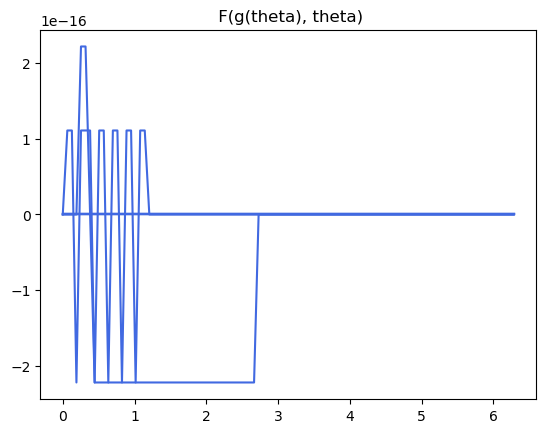

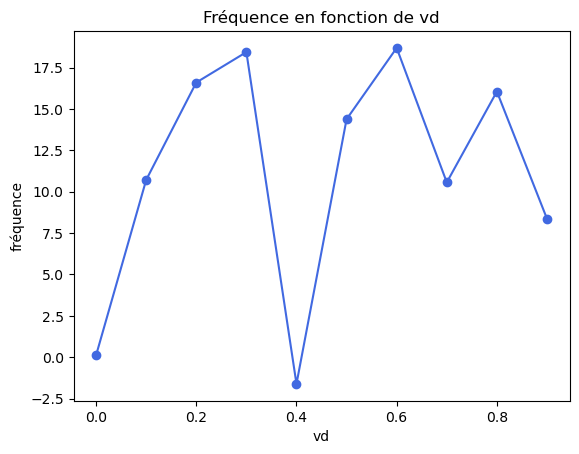

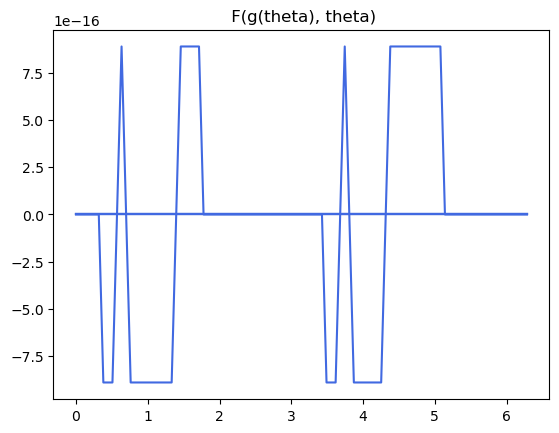

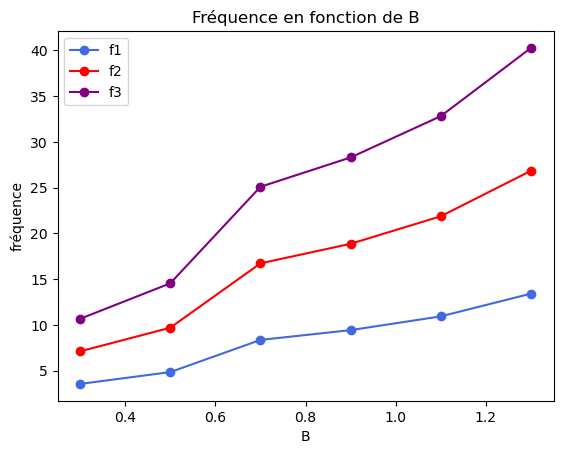

c:\Users\Hugo Johnson\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Hugo Johnson\anaconda3\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


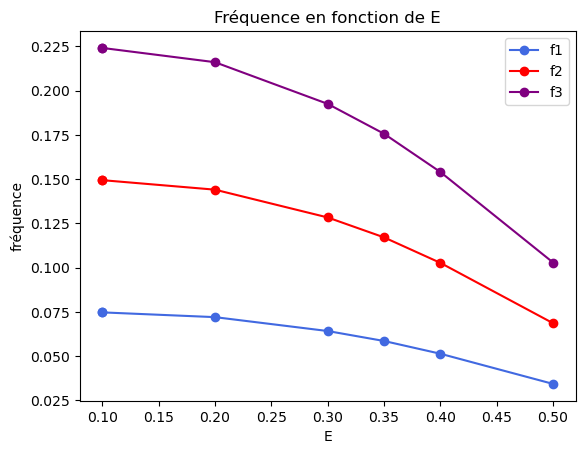

In [ ]:
###### QUE MAUVAIS A PARTIR D4ICI#############################
vd_tab = np.array([0, 0.1, 0.2, 0.3 , 0.4, 0.5, 0.6, 0.7, 0.8, 0.9 ])
periode_tab = np.zeros_like(vd_tab)

for i, vd in enumerate(vd_tab):
    py0 = vd * M / (vf * np.sqrt(vf**2 - vd**2))
    T = periode()
    periode_tab[i] = T

frequence = 1 / periode_tab
plt.figure()
plt.plot(vd_tab, frequence, marker='o', color='royalblue')
plt.xlabel("vd")
plt.ylabel("fréquence")
plt.title("Fréquence en fonction de vd")
plt.show()


B_tab = np.array([0.3, 0.5, 0.7, 0.9, 1.1, 1.3])
periode_tab2 = np.zeros_like(B_tab)

for i, B_val in enumerate(B_tab):
    G = e * B_val / c
    T = periode()
    periode_tab2[i] = T
frequence2 = 1 / periode_tab2
plt.figure()
plt.plot(B_tab, frequence2, marker='o', color='royalblue', label = "f1")
plt.plot(B_tab, 2 * frequence2, marker='o', color='red', label = "f2")
plt.plot(B_tab, 3 * frequence2, marker='o', color='purple', label= "f3")

plt.xlabel("B")
plt.ylabel("fréquence")
plt.title("Fréquence en fonction de B")
plt.legend()
plt.show()
# -------------------------------------------------------------------------------------------------------------

E_tab = np.array([ 0.1, 0.1 , 0.2, 0.3, 0.35, 0.4,  0.5, 0.6])
periode_tab3 = np.zeros_like(E_tab)
def p_system_energie(t, y):
    G =  (e * B / c)
    q, p = np.split(y, 2)
    y0 =  G * ((vf**2 * p / varepsilon(y)) + (E/B)) 
    y1 = -G * ((vf**2 * q / varepsilon(y)))
    return np.concatenate((y0,y1), axis=None)

vd = 0.5
B = 0.7
for i, E in enumerate(E_tab):
    
    T = find_periode(100, vd, B , E, p_system_energie)
    periode_tab3[i] = T
frequence3 = 1 / periode_tab3
plt.figure()
plt.plot(E_tab, frequence3, marker='o', color='royalblue', label = "f1")
plt.plot(E_tab, 2 * frequence3, marker='o', color='red', label = "f2")
plt.plot(E_tab, 3 * frequence3, marker='o', color='purple', label= "f3")

plt.xlabel("E")
plt.ylabel("fréquence")
plt.title("Fréquence en fonction de E")
plt.legend()
plt.show()

T = 4.441301202076809


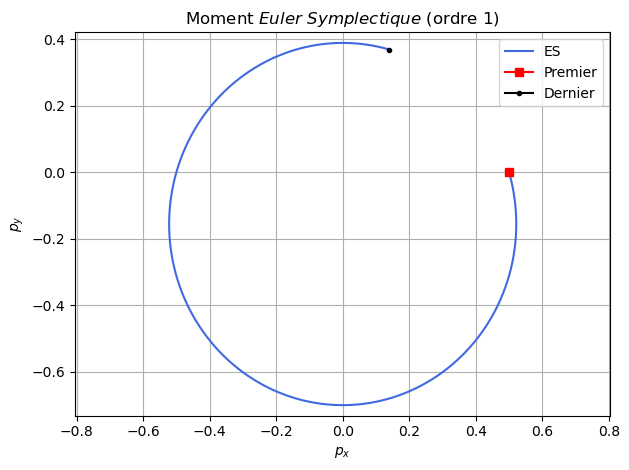

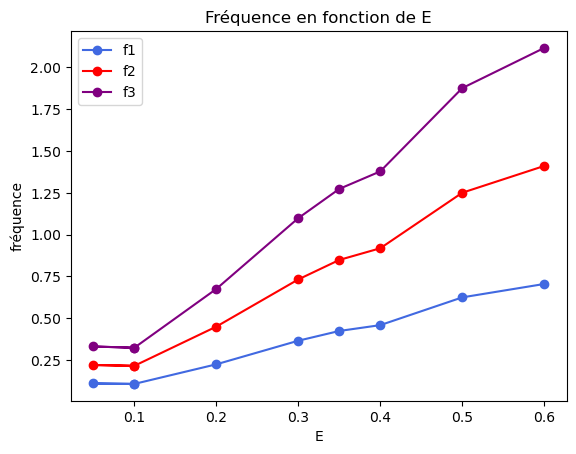

In [ ]:
# Paramètres physiques
e = 1
B = 0.7
c = 1
vf = 1.0
E = 0.2
M = 1.0
G = e * B / c
def periode_energie(E, N_theta=100):
    # Point d'équilibre
    py0 = -(E/B) * M / (vf * np.sqrt(vf**2 - (E/B)**2))

    # Condition initiale pour Newton
    px0 = 0.2
    py0 = 0
    r0 = np.sqrt(px0**2 + py0**2)

    # ---------------------------------------------------------------------------------------
    def esp(px, py):
        return np.sqrt(M**2 + vf**2 *(px**2 + (py - py0 )**2))

    def H(px, py):
        return G * (esp(px, py) + (E/B) * (py-py0))

    # ---------------------------------------------------------------------------------------
    def F(r, theta):
        px = r * np.cos(theta)
        py = r * np.sin(theta)

        return H(px, py) - H(0, py0)

    def Df(r, theta):
        denom = np.sqrt(M**2 + vf**2 * (r**2 - 2*r*np.sin(theta)*py0 + py0**2))
        return G * vf**2 * (r - np.sin(theta)*py0) / denom + G * (E/B) * np.sin(theta)
    # -----------------------------------------------------------------------------------------
    def g_newton(theta, r0, n_iter=100, tol=1e-16):
        r = r0
        for _ in range(n_iter):

            f  = F(r, theta)
            df = Df(r, theta)  

            r = r - f / df
            
            if abs(f) < tol:
                break
        return r

    
    thetas  = np.linspace(0, 2*np.pi, N_theta)
    valeurs = np.zeros(N_theta)
    # residus = np.zeros(N_theta)
    
    r = r0
    for i, t in enumerate(thetas):
        
        g_theta = g_newton(t, r)
        # residus[i] =(F(g_theta, t))
        df = Df(g_theta, t)
        valeurs[i] = g_theta / df       
        
    # plt.plot(thetas, residus, color="royalblue") # pour vérifier que Newton marche bien
    # plt.title(" F(g(theta), theta)")

    Periode = np.trapezoid(valeurs, thetas, dx=thetas[1]-thetas[0])
    return Periode
#---------------------------------------------------------------------------------------
T= periode_energie(E)
print(f"T = {T}")

Moment_ES = ES(deltaT, T , P, e, B, vf, c, varepsilon, (E/B))

plt.figure()
plt.plot(Moment_ES[:, 0], Moment_ES[:,1], color='royalblue',label='ES')
plt.plot(Moment_ES[1, 0], Moment_ES[0,1], marker='s', color='red',label='Premier')
plt.plot(Moment_ES[-1, 0], Moment_ES[-1, 1], marker='.', color='black',label='Dernier')

plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.title(r'Moment $Euler \ Symplectique$ (ordre 1)')
plt.axis('equal')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

E_tab = np.array([ 0.1, 0.05, 0.1 , 0.2, 0.3, 0.35, 0.4,  0.5, 0.6])
periode_tab3 = np.zeros_like(E_tab)

for i, E in enumerate(E_tab):
    r0 = E
    T = periode_energie(E)
    periode_tab3[i] = T
frequence3 = 1 / periode_tab3
plt.figure()
plt.plot(E_tab, frequence3, marker='o', color='royalblue', label = "f1")
plt.plot(E_tab, 2 * frequence3, marker='o', color='red', label = "f2")
plt.plot(E_tab, 3 * frequence3, marker='o', color='purple', label= "f3")

plt.xlabel("E")
plt.ylabel("fréquence")
plt.title("Fréquence en fonction de E")
plt.legend()
plt.show()

In [ ]:
# On défini une fonction période proprement maintenant
def periode_systeme(px0, py0, N_theta = 100, vd, ):
    py0 = vd * M / (vf * np.sqrt(vf**2 - vd**2))

    # Condition initiale pour Newton
    px0 = 10
    py0 = 0
    r0 = np.sqrt(px0**2 + py0**2)

    # ---------------------------------------------------------------------------------------
    def esp(px, py):
        return np.sqrt(M**2 + vf**2 *(px**2 + (py - py0 )**2))

    def H(px, py):
        return G * (esp(px, py) + vd * (py-py0))

    # ---------------------------------------------------------------------------------------
    def F(r, theta):
        px = r * np.cos(theta)
        py = r * np.sin(theta)

        return H(px, py) - H(0, py0)

    def Df(r, theta):
        denom = np.sqrt(M**2 + vf**2 * (r**2 - 2*r*np.sin(theta)*py0 + py0**2))
        return G * vf**2 * (r - np.sin(theta)*py0) / denom + G * vd * np.sin(theta)
    # -----------------------------------------------------------------------------------------
    def g_newton(theta, r0, n_iter=100, tol=1e-16):
        r = r0
        for _ in range(n_iter):

            f  = F(r, theta)
            df = Df(r, theta)  

            r = r - f / df
            
            if abs(f) < tol:
                break
        return r

    
    thetas  = np.linspace(0, 2*np.pi, N_theta)
    valeurs = np.zeros(N_theta)
    # residus = np.zeros(N_theta)
    
    r = r0
    for i, t in enumerate(thetas):
        
        g_theta = g_newton(t, r)
        # residus[i] =(F(g_theta, t))
        df = Df(g_theta, t)
        valeurs[i] = g_theta / df
        
        
        
    # plt.plot(thetas, residus, color="royalblue") # pour vérifier que Newton marche bien
    # plt.title(" F(g(theta), theta)")

    Periode = np.trapezoid(valeurs, thetas, dx=thetas[1]-thetas[0])
    return Periode

### Résolution du cas Fermions proprement (c'est faux)

On écrit le système initial en posant comme d'habitude $G = \dfrac{eB}{c}$ :
$$
\begin{cases}
p_x' = G \times \left(\dfrac{v_F^2 \ p_y}{\varepsilon(p)} + v_d \right) \\
p_y' = G \times \dfrac{v_F^2 \ p_x}{\varepsilon(p)}
\end{cases}
$$
Où $\varepsilon(p) = \big(M^2 + v_F^2(p_x^2 + p_y^2)\big)^{1/2} $.

Ce système n'est pas à l'équilbre en (0,0) ce qui est nécessaire pour utiliser notre théorème.
On pose alors $\tilde{p_x} = p_x $ et $\tilde{p_y} = \dfrac{\varepsilon(p) v_d}{v_F^2} + p_y$.
Le système devient:
$$
\begin{cases}
p_x' = G \times \left(\dfrac{v_F^2 \ \bigg(\tilde{p_y} - \dfrac{\varepsilon(p) v_d}{v_F^2}\bigg) }{\varepsilon(p)} + v_d \right) \\ \\
p_y' = G \times \dfrac{v_F^2 \ \tilde{p_x}}{\varepsilon(p)}
\end{cases}
$$
C'est à dire en simpifiant:
$$
\begin{cases}
p_x' = \dfrac{G \ v_F^2 \ \tilde{p_y}}{\varepsilon(p)}  \\ \\
p_y' = \dfrac{G \ v_F^2 \ \tilde{p_x}}{\varepsilon(p)}
\end{cases}
$$
On doit maintenant réexprimer les dérivées en notation tild:
$$
\begin{aligned}
\tilde{p_x} = p_x &\Longrightarrow \tilde{p_x}' = p_x' \\ \\ 
\tilde{p_y} = \dfrac{\varepsilon(p) v_d}{v_F^2} + p_y &\Longrightarrow \tilde{p_y}' = \dfrac{v_d}{\varepsilon(p)}(p_x p_x' + p_y p_y') + p_y'
\end{aligned}
$$
Ainsi:
$$
\begin{cases}
\tilde{p_x}' = \dfrac{G \ v_F^2 \ \tilde{p_y}}{\varepsilon(p)}  \\ \\
\tilde{p_y}' = \dfrac{G \ v_F^2 \ \tilde{p_x}}{\varepsilon(p)} + \dfrac{v_d}{\varepsilon(p)}(p_x p_x' + p_y p_y')
\end{cases}
$$

Le terme $p_x p_x' + p_y p_y'$ doit être écrit plus simplement, on utile les faits suivants:
$$
\begin{aligned}

p_x &=  \tilde{p_x} \\
p_x' &= \tilde{p_x}' \\
\tilde{p_x}' &= \dfrac{G \ v_F^2 \ \tilde{p_y}}{\varepsilon(p)} \\
p_y &= \tilde{p_y} - \dfrac{\varepsilon(p) v_d}{v_F^2} \\
p_y' &= \dfrac{G \ v_F^2 \ \tilde{p_x}}{\varepsilon(p)} 

\end{aligned}
$$
On peut alors écrire:
$$
\begin{aligned}
\tilde{p_y}' &= \dfrac{G \ v_F^2 \ \tilde{p_x}}{\varepsilon(p)} + \dfrac{v_d}{\varepsilon(p)}(p_x p_x' + p_y p_y') \\ \\ 
&= \dfrac{G \ v_F^2 \ \tilde{p_x}}{\varepsilon(p)} + \dfrac{v_d}{\varepsilon(p)}\left(\tilde{p_x}\dfrac{G \ v_F^2 \ \tilde{p_y}}{\varepsilon(p)} + (\tilde{p_y} - \dfrac{\varepsilon(p) v_d}{v_F^2})\dfrac{G \ v_F^2 \ \tilde{p_x}}{\varepsilon(p)}\right) \\ \\

&= \dfrac{G \ v_F^2 \ \tilde{p_x}}{\varepsilon(p)} + \dfrac{2 G \ v_F^2\ v_d \ \tilde{p_x}\tilde{p_y}}{\varepsilon(p)^2} - \dfrac{G \ v_d^2 \ \tilde{p_x}}{\varepsilon(p)} \\ \\
&= \tilde{p_x} \left( \dfrac{G}{\varepsilon(p)}(v_F^2-v_d^2) + \dfrac{2G \ v_F^2 \ v_d \ \tilde{p_y}}{\varepsilon(p)^2} \right)
\end{aligned}
$$
Pour tout écrire en fonction de "tild" il nous reste à réécrire $\varepsilon(p)$ en fonction de $\varepsilon(\tilde{p})$ mais c'est plus compliqué et peut être pas nécessaire...
En effet on a posé $\tilde{p_y} = \dfrac{\varepsilon(p) v_d}{v_F^2} + p_y$, si nomme $ p_y^0 := \dfrac{\varepsilon(p) v_d}{v_F^2} $ alors ce $p_y^0$ réapparait dans l'écriture de $\varepsilon(p)$... On doit au minimum conserver l'information de $p_y$ ce qui nous donne:
$$
\varepsilon(p) = \sqrt{\varepsilon(\tilde{p})^2 - v_F^2 ( \tilde{p_y} - p_y)(2\tilde{p_y} - 1)}
$$
Bref si on met de côté ce détail on obtient le résultat suivant qui est je l'espère sufisant.

$$
\begin{cases}
\tilde{p_x}' = \dfrac{G \ v_F^2 \ \tilde{p_y}}{\varepsilon(p)}  \\ \\
\tilde{p_y}' = \tilde{p_x} \left( \dfrac{G}{\varepsilon(p)}(v_F^2-v_d^2) + \dfrac{2G \ v_F^2 \ v_d \ \tilde{p_y}}{\varepsilon(p)^2} \right)
\end{cases}
$$
Et nous posons désormais
$$
\begin{cases}
\tilde{p_x}' = \partial_{\tilde{p_y}} \tilde{\mathcal{H}}(\tilde{p_x}, \tilde{p_y}) \\
\tilde{p_y}' = - \partial_{\tilde{p_x}} \tilde{\mathcal{H}}(\tilde{p_x}, \tilde{p_y})
\end{cases}
$$

De sorte que le point d'équilbre soit cette fois bien en $(0,0)$ !
C'est à ce système qu'on applique le théorème que l'on résume ci-dessous pour trouver la période.

--------------------------------------------------------------------------------------------------------------
Soit $\mathcal{T}$ la période que l'on cherche à calculer, alors:
$$
\mathcal{T} = \int^{2\pi}_0 \dfrac{d\theta}{\mathcal{F}(\theta)}
$$
Avec:
$$
\mathcal{F}(\theta) = \dfrac{\partial_r F(g(\theta), \theta)}{g(\theta)}
$$
En précisant que:
$$
\begin{aligned}
F(r,\theta) &= H(r\cos(\theta), r\sin(\theta)) - H(p0, q0) \\
F(g(\theta), \theta) &= 0
\end{aligned}
$$
Où $(p0, q0) = (0,0)$ est le point d'équilibre et g est défini implictement.

---------------------------------------------------------------------------------------------------------------


